In [62]:
import json
import numpy as np
import jax.numpy as jnp

from compile_from_dict import numpy_compile, jax_compile
import pandas as pd
import corner
import matplotlib.pyplot as plt

import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 16

In [2]:
model_name = 'M4-test'
with open(f'models/{model_name}.json', 'r') as fp:
    model_dict = json.load(fp)

jax.config.update('jax_enable_x64', True)

In [3]:
jax_model = jax_compile(model_dict,)

In [4]:
seed = 42

df_full = pd.read_hdf('../M4/grids/Chiara-dnufit.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnufit'] = np.log10(df_full['dnufit'])

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnufit'] 

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())
df_train = df.sample(frac=0.95, random_state=seed)
df_test_norm = df_norm.drop(df_train.index)
df_test = df.drop(df_train.index)
df_small = df_full.sample(1000)


# Maddy Pbjam only 

In [20]:
case = 'C'

M22 = pd.read_csv('../M4/data/M4_obs_Howell_pbjam_lum_vary.csv')

#M22 = M22[~M22['star_id'].isin(['M4RGB252', 'M4RGB238', 'M4RGB217', 'M4RGB165', 'M4RGB131', 'M4RGB34', 'M4RGB25', 'M4RGB22', 'M4RGB16'])].reset_index()[0:33]

M22 = M22[~(M22['Quality_flag'] == 'MD')][0:30].reset_index()

IDs = M22['star_id']

dnu = M22['dnu_pbjam'].values
ednu_obs = M22['ednu_pbjam'].values
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = M22[f'LPhot_case{case}'].values
eLPhot_obs = np.sqrt(M22['Lum_bol_err_random'].values**2 + M22['Lum_bol_err_systematic'].values**2)
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = M22['Teff_final'].values
eTeff = M22['Teff_err_final'].values

FeH = M22['[Fe/HI]'].values

numax = M22['numax_pbjam'].values
enumax_obs = M22['enumax_pbjam'].values
enumax_pred = 0.009*numax
enumax= np.sqrt(enumax_pred**2 + enumax_obs**2)

maxes_in = df[inputs].max().values
mins_in = df[inputs].min().values
maxes_out = df[outputs].max().values
mins_out = df[outputs].min().values


obs = {'FeH':FeH,  'Teff':Teff, 'dnuSer':dnu,'logLPhot':np.log10(LPhot), 'LPhot':LPhot, 'numax':numax}
unc = {'Teff':eTeff, 'dnuSer':ednu, 'FeH':0.05*np.ones_like(Teff), 'logLPhot':eLPhot/LPhot*1/np.log(10), 'LPhot':eLPhot, 'numax':enumax, }
#unc['Teff'] = 150*np.ones_like(Teff)

num_stars = len(Teff)

In [21]:
obs_values = np.full((len(outputs) + 3), None)
        
obs_dict = {}
        
for key, value in zip(outputs + ['LPhot', 'numax', 'dnuSer'], obs_values):
    if key not in obs_dict:
        obs_dict[key] = value
    else:
        obs_dict[key].append(value)

In [22]:
def massfromage(age):
    logage = np.log(age)
    return np.exp(-0.3*logage + 2.4)

def lnsigmoid(x, k, mini, spread):
    s = k*(x - mini)/spread
    y = (1 + jnp.exp(-s))
    return -1*jnp.log(y)

def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [69]:
def shared_2param(uncs,  obs = obs_dict):

    age = sample_beta('age', 8000, 7000, alpha = 10, beta = 10)

    std_age = sample_beta('std_age', 100, 900, alpha = 2, beta = 2)

    zini = sample_beta('zini', 0.5*0.01756*10**-1.1, 2*0.01756*10**-1.1, alpha = 2, beta = 2) #This is probably far too conservative 

    alphaMLT = sample_beta('alphaMLT', 1.5, 0.5, alpha = 1.5, beta = 1.5)
    
    yini = sample_beta('yini', 0.248, 0.05, alpha = 1.5, beta = 5)

    eta = sample_beta('eta', 0.0004, 0.29, alpha = 1.5, beta = 1.5)

    alphaFe = sample_beta('alphaFe', 0.31, 0.15, alpha = 5, beta = 5) #Proxy for a normal distribution

    fnumax = numpyro.sample("fnumax", dist.Normal(1.14, 0.05))

    fdnu = numpyro.sample("fdnu", dist.Normal(1.0109, 0.01))

    dT = sample_beta('dT', -50, 200, alpha = 3, beta = 3)
    
    with numpyro.plate("star", num_stars):    
   
        tau = sample_beta('tau', 1.0, 0.5, alpha = 2, beta = 2)

        star_age = numpyro.sample('star_age', dist.StudentT(df = 5, loc = age, scale = std_age))

        star_zini = jnp.stack([zini for i in range(num_stars)], axis = 0)
        
        star_yini = jnp.stack([yini for i in range(num_stars)], axis = 0)

        star_aMLT = jnp.stack([alphaMLT for i in range(num_stars)], axis = 0)

        star_eta = jnp.stack([eta for i in range(num_stars)], axis = 0)

        star_aFe = jnp.stack([alphaFe for i in range(num_stars)], axis = 0)

        massini = numpyro.deterministic('massini', tau*jnp.exp(-0.3*jnp.log(star_age) + 2.4)) #I got the values in here from fitting the distribution in the grid and then varying the offset such that its a lower bound (a bit naff, I know)

        numpyro.factor('logfac',lnsigmoid(massini, 10, 0.7, 0.01))

        params_unnorm = jnp.stack([massini, star_zini, star_yini, star_aMLT, jnp.log10(star_age), star_eta, star_aFe], axis = -1)

        params_norm = (params_unnorm - mins_in)/(maxes_in - mins_in)

        pred_norm = jax_model.jit_forward_pass(params_norm)
        
        pred = pred_norm*(maxes_out - mins_out) + mins_out

    Teff_pred = pred[:, 2] + dT

    numax_pred = fnumax*10**pred[:, 3]

    dnu_pred = 1/fdnu*10**(pred[:, 4])

    L_pred = 10**pred[:, 1]

    FeH = numpyro.sample("FeH", dist.StudentT(df = 10, loc = pred[:, 0], scale = uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.StudentT(df = 10, loc = L_pred, scale = uncs['LPhot']), obs=obs['LPhot'])
    
    Teff = numpyro.sample("Teff", dist.StudentT(df = 10, loc = Teff_pred, scale = uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.StudentT(df = 10, loc = numax_pred, scale = uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.StudentT(df = 10, loc = dnu_pred, scale = uncs['dnuSer']), obs=obs['dnuSer'])

 



In [70]:
num_warmup, num_samples = 4000,4000 
#10000, 8000 works with stars 6, 16
num_chains = 1

sampler = NUTS(shared_2param, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_sample) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [71]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(shared_2param, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)

(array([ 15.,  64., 124., 150., 151., 160., 161., 103.,  58.,  14.]),
 array([-40.5350622 , -21.89672737,  -3.25839253,  15.3799423 ,
         34.01827714,  52.65661198,  71.29494681,  89.93328165,
        108.57161648, 127.20995132, 145.84828615]),
 <BarContainer object of 10 artists>)

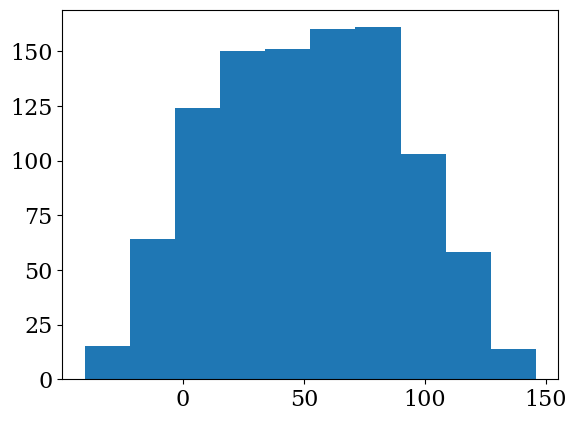

In [72]:
plt.hist(prior['dT'])

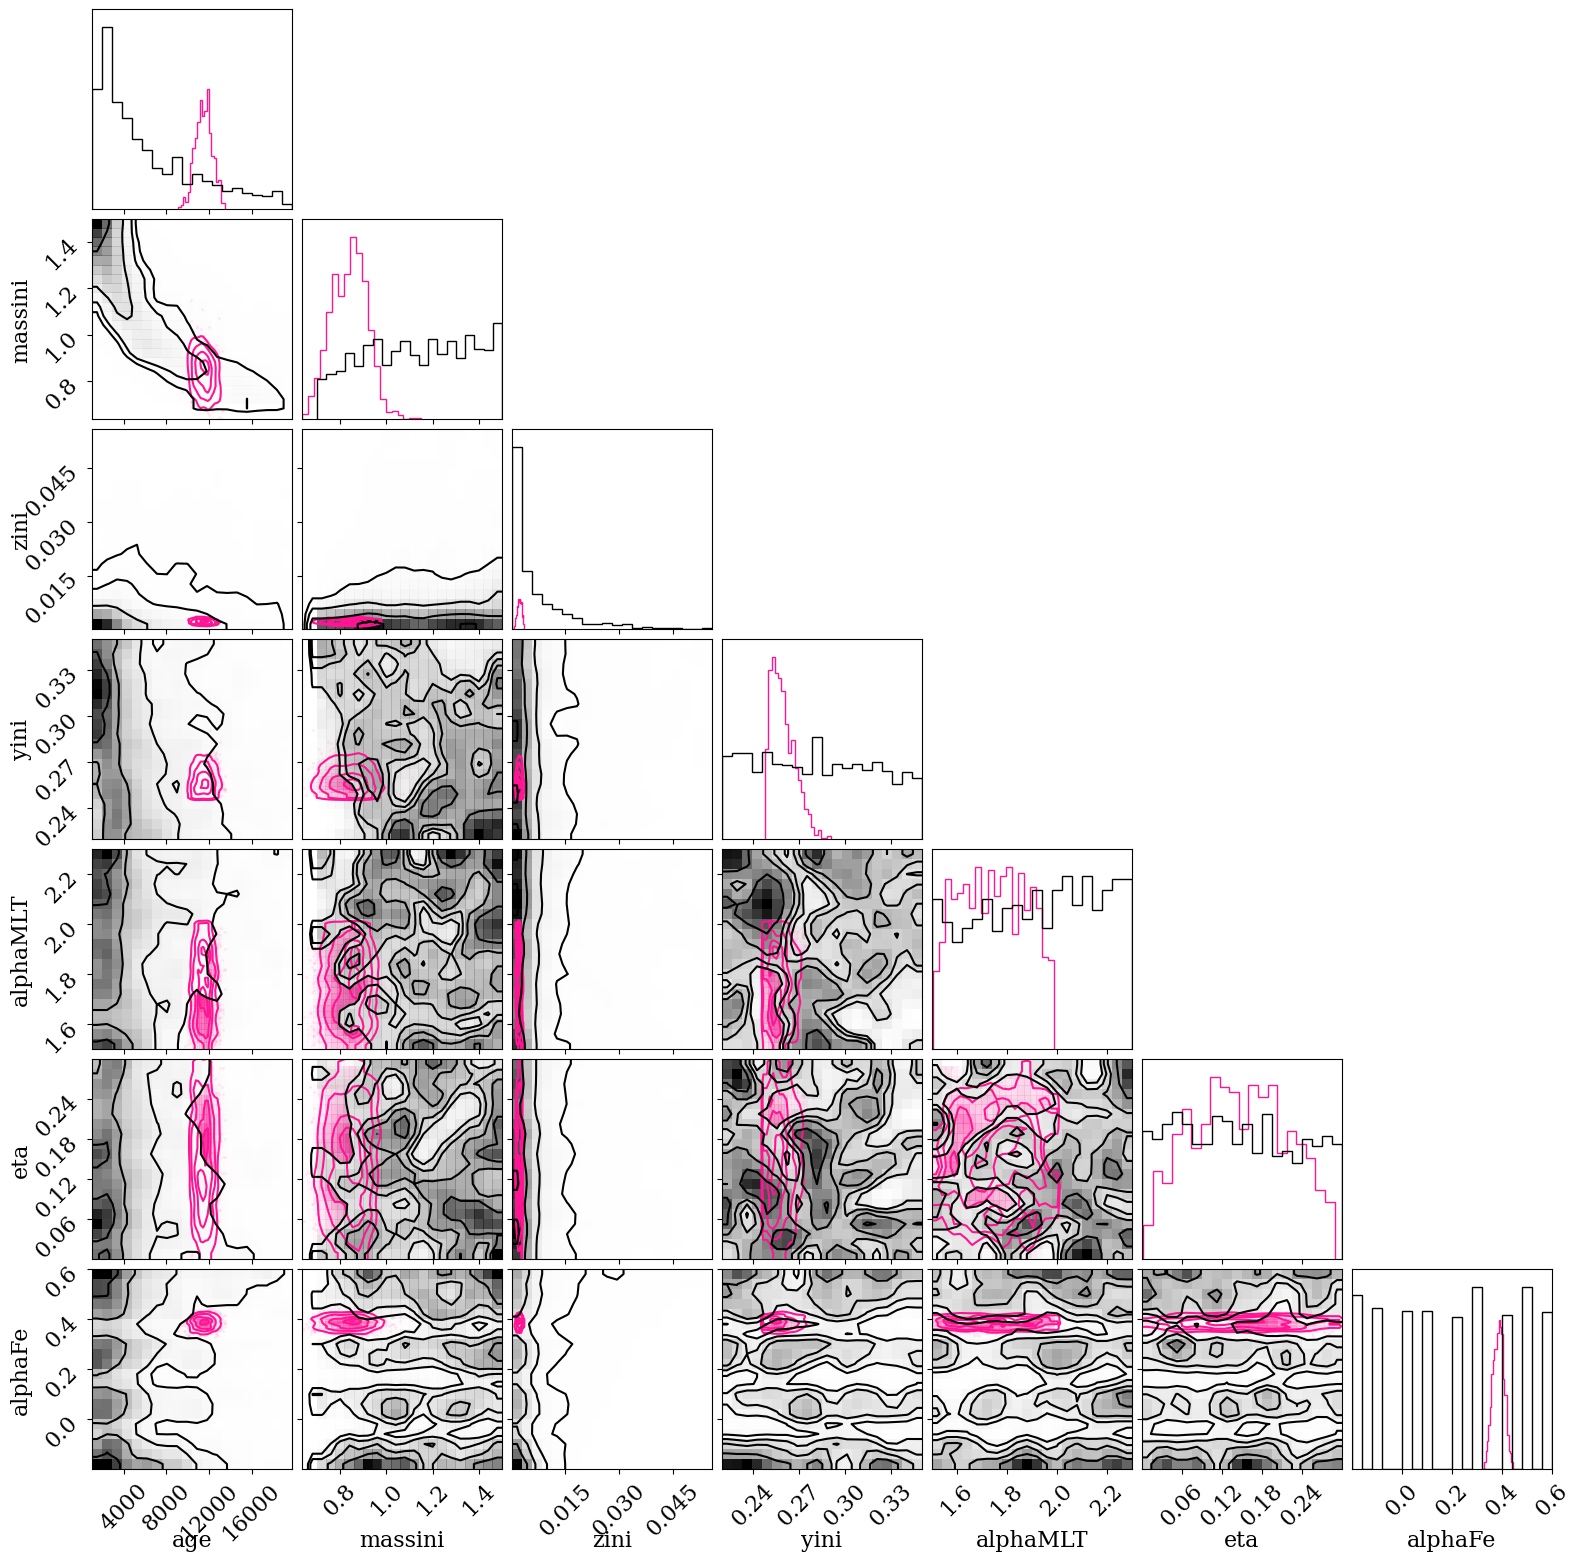

In [73]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini','zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', smooth = True, plot_datapoints = True,  weights = np.ones(num_prior_samples)/(num_prior_samples), zorder = 100, coords = {'star':1})
corner.corner(df_small[['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']],zorder = 0, alpha = 0.1, fig = fig, smooth = True, weights = np.ones_like(df_small['massini'])/len(df_small), plot_datapoints = False,)
plt.show()

In [74]:
mcmc.run(jax.random.PRNGKey(0),  uncs=unc, obs=obs)

mcmc.print_summary()

sample: 100%|███████████████████████████████████████████████████████████████████| 8000/8000 [2:04:28<00:00,  1.07it/s, 1023 steps of size 5.26e-04. acc. prob=0.96]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
       age_beta      0.61      0.02      0.61      0.57      0.65     11.77      1.00
   alphaFe_beta      0.48      0.13      0.48      0.24      0.68     33.84      1.01
  alphaMLT_beta      0.34      0.08      0.34      0.22      0.46     51.46      1.01
        dT_beta      0.58      0.14      0.59      0.37      0.80     63.56      1.00
       eta_beta      0.43      0.22      0.39      0.10      0.79     26.16      1.08
           fdnu      1.02      0.01      1.02      1.00      1.03     43.38      1.01
         fnumax      1.13      0.01      1.13      1.11      1.15     39.04      1.01
    star_age[0]  12110.07    397.28  12153.77  11432.93  12648.95      5.39      1.03
    star_age[1]  12477.01    554.66  12436.17  11576.28  13462.33     29.81      1.05
    star_age[2]  12163.47    621.29  12163.26  10919.20  12950.95     25.45      1.05
    star_age[3]  11996.13    605.02  12046.56  10978.

In [628]:
obs['FeH'][~(obs['FeH'] == -1.047)]

array([-1.03, -1.08, -1.08, -0.99, -1.05, -1.11, -1.08, -0.99, -1.08,
       -1.03])

In [75]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(shared_2param, posterior_samples=posterior, parallel=True, batch_ndims=2)

post_obs = posterior_predictive(rng_key, uncs = unc)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims, )


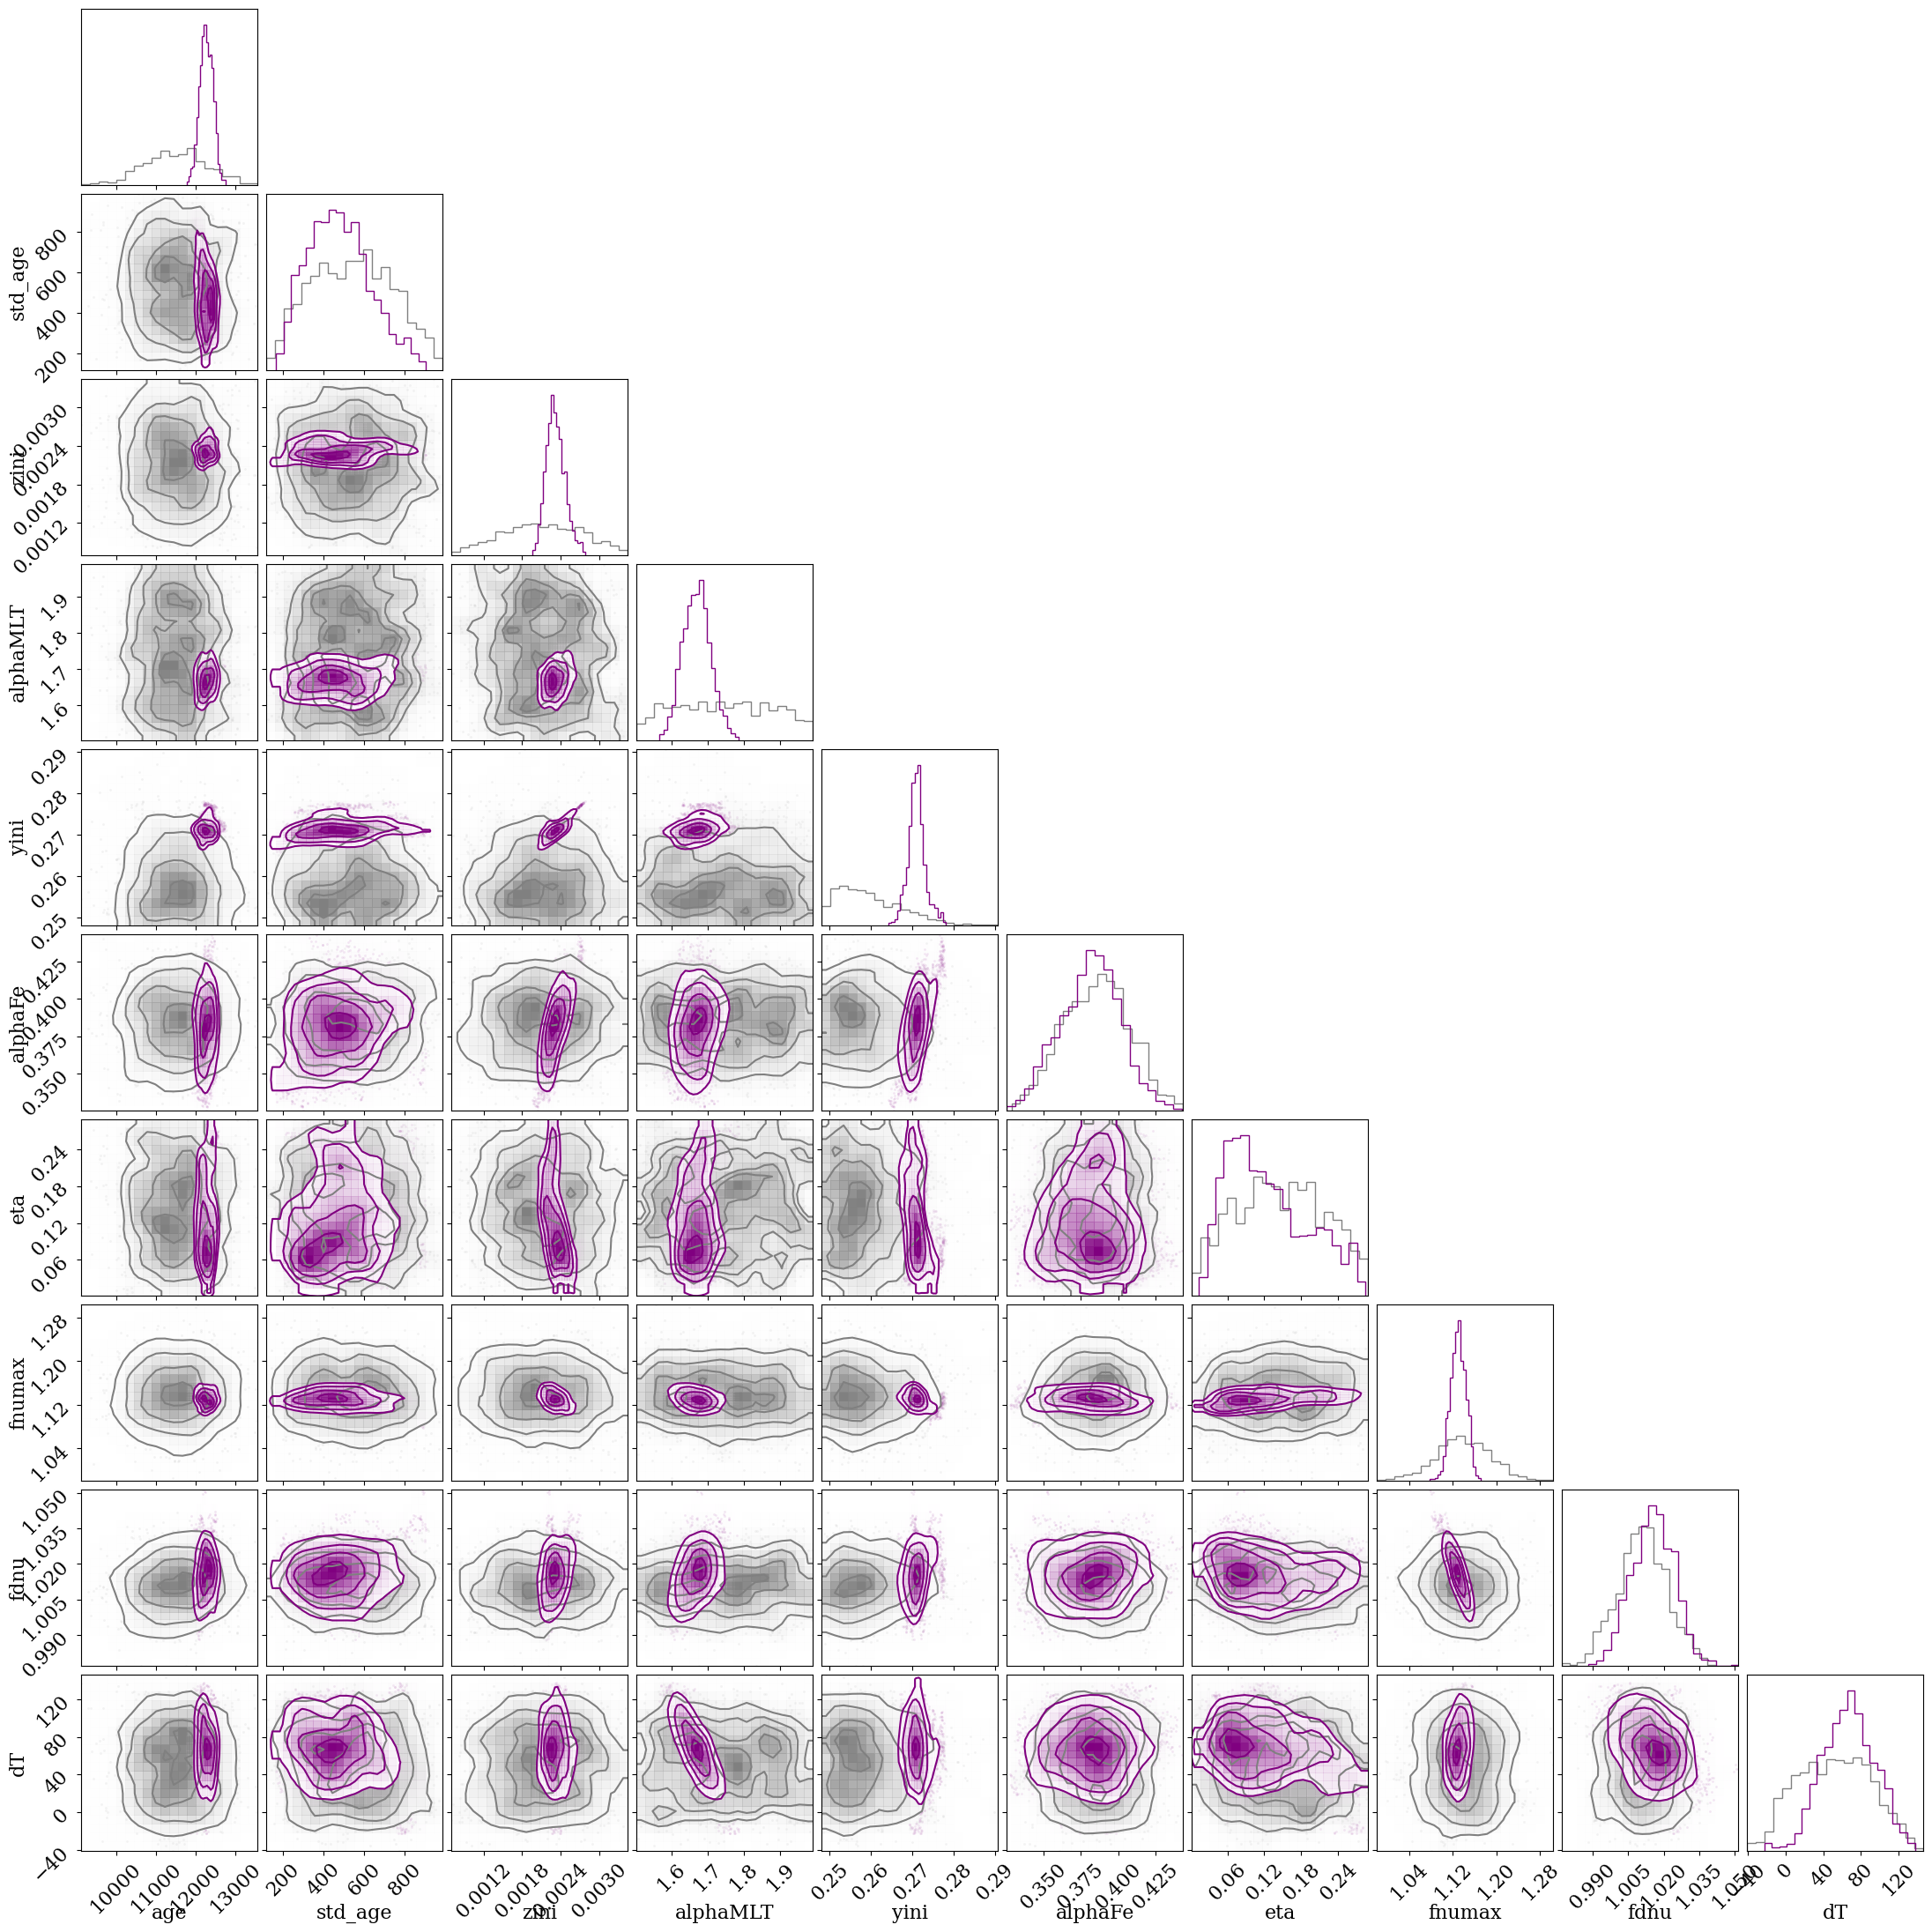

In [76]:
fig = corner.corner(data, group="prior", var_names = ['age', 'std_age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta', 'fnumax', 'fdnu','dT'], color = 'grey', smooth = True, hist_kwargs={'density':True})
corner.corner(data, group="posterior", var_names = ['age', 'std_age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta', 'fnumax', 'fdnu', 'dT'], color = 'purple',  smooth = True, fig = fig, hist_kwargs={'density':True})
#fig.savefig(f'../M4/figs/corner-pbjam-maddy-dT-fdnu-fnumax-case-{case}.png', bbox_inches ='tight', dpi = 150)
plt.show()

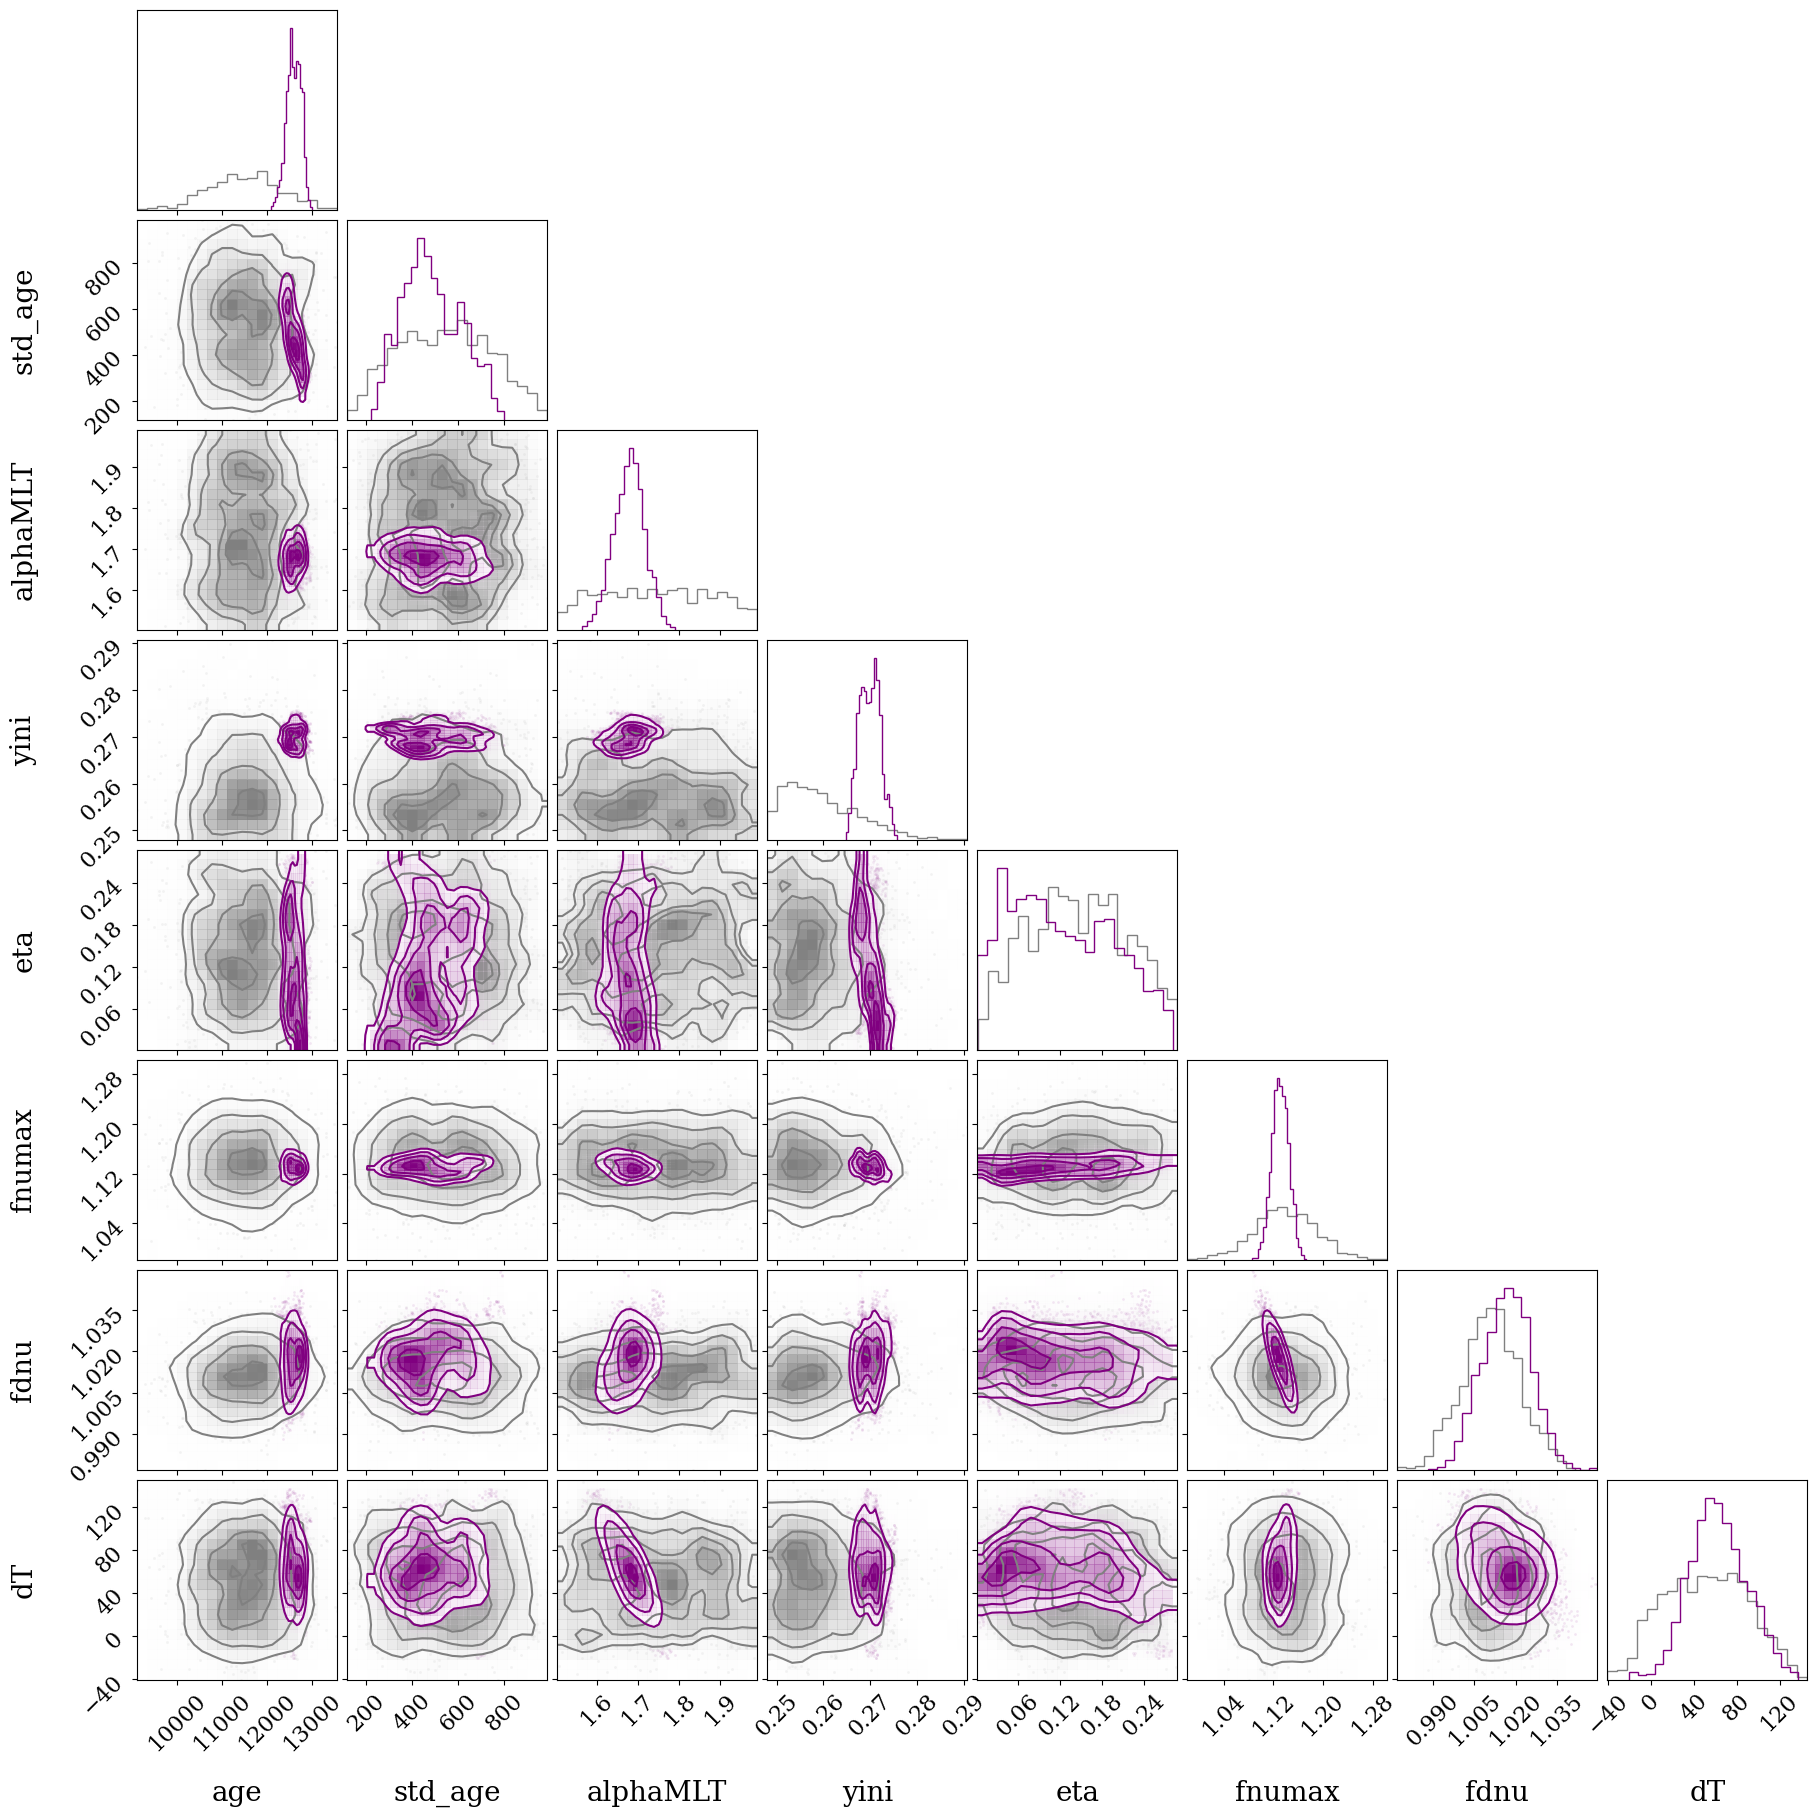

In [65]:
fig = corner.corner(data, group="prior", var_names = ['age', 'std_age', 'alphaMLT', 'yini', 'eta', 'fnumax', 'fdnu','dT'], color = 'grey', smooth = True, hist_kwargs={'density':True},  label_kwargs={ 'fontsize':20}, tick_kwargs={'fontsize':16}, labelpad = 0.2)
corner.corner(data, group="posterior", var_names = ['age', 'std_age', 'alphaMLT', 'yini',  'eta', 'fnumax', 'fdnu', 'dT'], color = 'purple',  smooth = True, fig = fig, hist_kwargs={'density':True},  label_kwargs={ 'fontsize':20}, tick_kwargs={'fontsize':16}, labelpad = 0.2)
plt.show()

In [51]:
az.to_json(data, f'../M4/results-partially-pooled-age-pbjam-maddy-dT-fdnu-fnumax-case-{case}.json')

'../M4/results-partially-pooled-age-pbjam-maddy-dT-fdnu-fnumax-case-C.json'

In [545]:
fig.savefig('../M4/figs/corner-hbm-fnumax-fdnu-maddy-marco-0-30.png', bbox_inches = 'tight', dpi = 150)

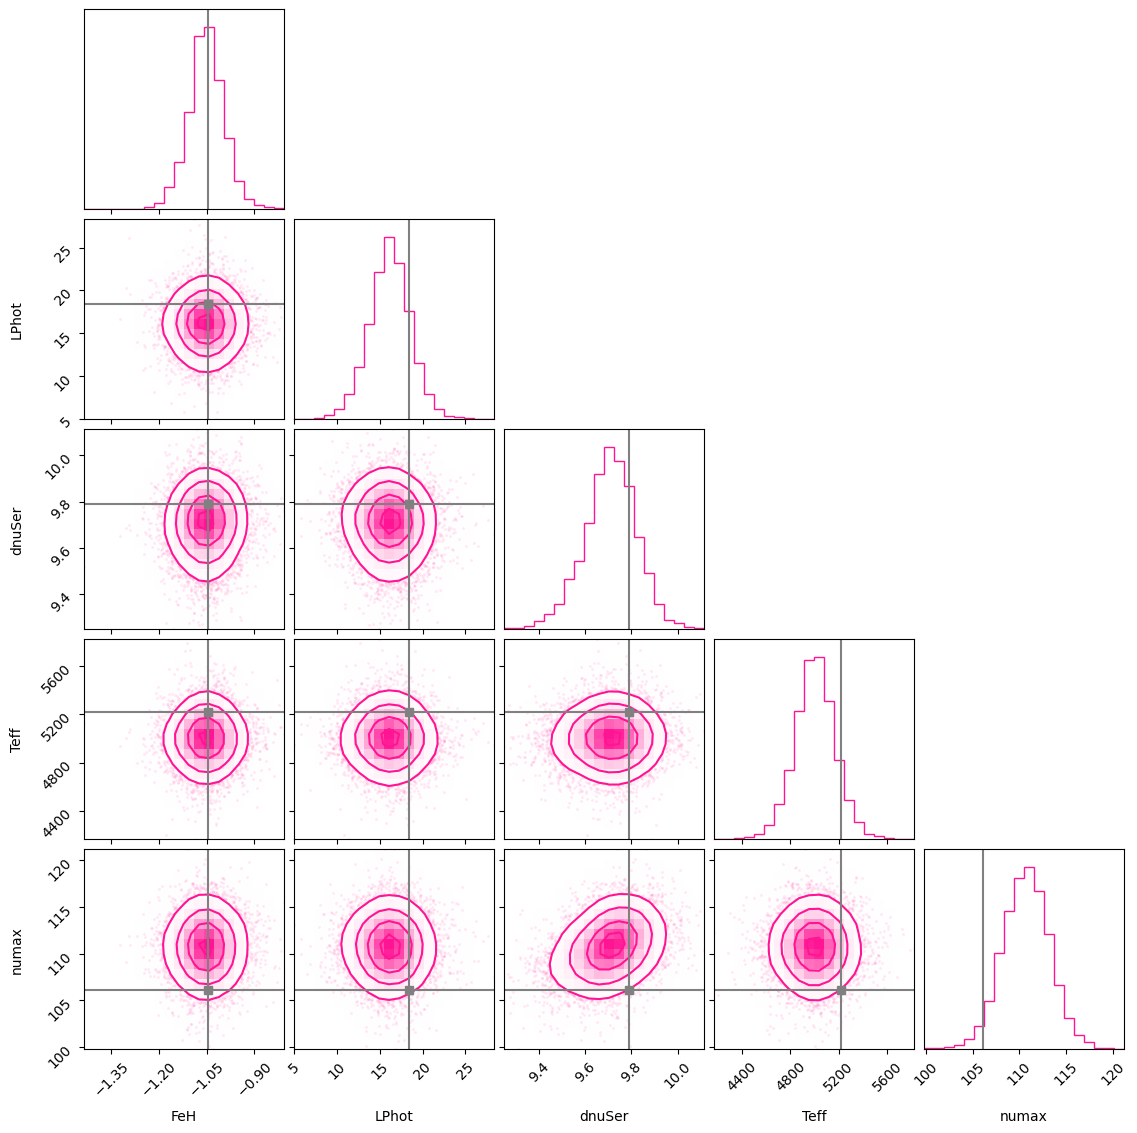

In [99]:
post_pred = az.from_dict(post_obs, coords=coords, dims=dims,)
star = 8
fig = corner.corner(post_pred, group = "posterior", var_names = ['FeH', 'LPhot', 'dnuSer', 'Teff', 'numax'],  color = 'deeppink', smooth = True, plot_datapoints = True, hist_kwargs={'density':True}, coords = {'star':star}, truths = [FeH[star], LPhot[star], dnu[star], Teff[star], numax[star]], truth_color = 'grey')